# PointillSim: Histological Elements and Cell Type Rules

This notebook explores the building blocks for creating complex tissue architectures:

1. **Histological Elements**: Bounded regions that define tissue structures
2. **Cell Type Rules**: Algorithms that assign cell type probabilities based on spatial context
3. **Composing Elements**: Building multi-structure simulations

## Contents

1. **Histological Elements Overview**
2. **HistologicalElement**: Basic bounded structures
3. **VacuolatedStructure**: Structures with central holes
4. **Cell Type Assignment Rules**
   - RandomCellTypeRule
   - SingleTypeRule
   - MixOfNCellTypesRule
   - DistanceBasedRule
   - CompositeRule
5. **Combining Background and Foreground**
6. **Complex Simulation Examples**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import pandas as pd

np.random.seed(42)

# Import PointillSim components
from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOV,
    FOVDistribution,
    FrameWideElement,
    HistologicalElement,
    VacuolatedStructure,
    # Rules
    RandomCellTypeRule,
    SingleTypeRule,
    MixOfNCellTypesRule,
    DistanceBasedRule,
    CompositeRule,
    # Utils
    IdentityTransfer,
    smooth_polygon,
    chaikin_smooth,
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

---
## 1. Histological Elements Overview

PointillSim models tissue as a composition of **histological elements** - discrete regions with:

- A **bounding polygon** defining their spatial extent
- A **cell population** placed within the polygon
- **Cell type rules** that assign probabilities to each cell

### Available Element Types

| Element | Description | Use Case |
|---------|-------------|----------|
| `FrameWideElement` | Fills the entire FOV | Background tissue |
| `HistologicalElement` | Convex polygon with cells | Discrete structures |
| `VacuolatedStructure` | Polygon with central hole | Glands, vessels |

---
## 2. HistologicalElement: Basic Bounded Structures

`HistologicalElement` is the base class for bounded tissue regions. It generates:
1. A convex polygon from random points within a circle
2. Cell centroids on a quasi-hexagonal grid
3. Cell type probabilities via rules

In [2]:
# Create a simple histological element
n_cell_types = 5

element = HistologicalElement(
    frame_size=500,
    n_vertices=(8, 12),           # Random number of vertices in this range
    scale=100,                     # Approximate radius
    fixed_center=np.array([[250, 250]]),  # Center position
    tipical_cell_spacing=10,      # Cell density
    rules=RandomCellTypeRule(n_cell_types=n_cell_types)
)

# Generate a realization
realized = element.generate()

print(f"Generated element with {len(realized.cell_centroids)} cells")
print(f"Polygon has {len(realized.polygon.exterior.coords)-1} vertices")

Generated element with 40 cells
Polygon has 6 vertices


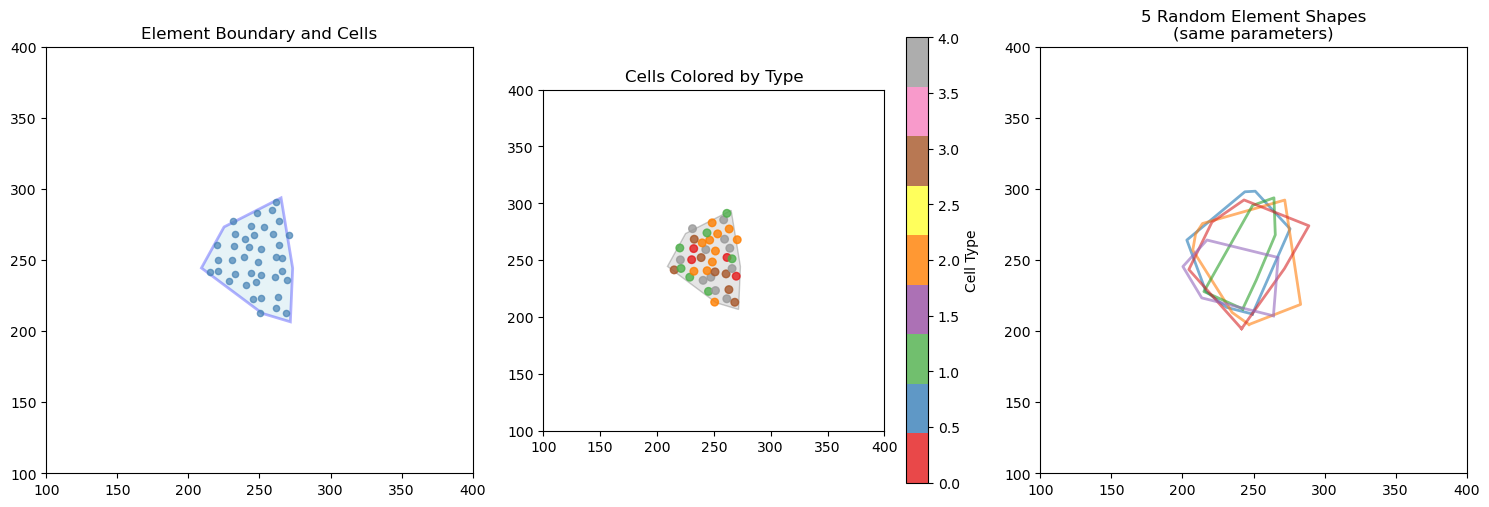

In [3]:
# Visualize the element
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Polygon boundary and cells
ax = axes[0]
# Draw polygon
x, y = realized.polygon.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2)
# Draw cells
ax.scatter(realized.cell_centroids[:, 0], realized.cell_centroids[:, 1], 
           s=20, c='steelblue', alpha=0.7)
ax.set_xlim(100, 400)
ax.set_ylim(100, 400)
ax.set_aspect('equal')
ax.set_title('Element Boundary and Cells')

# Plot 2: Cells colored by type
ax = axes[1]
x, y = realized.polygon.exterior.xy
ax.fill(x, y, alpha=0.2, fc='gray', ec='black', linewidth=1)
scatter = ax.scatter(realized.cell_centroids[:, 0], realized.cell_centroids[:, 1],
                     c=realized.class_instance, cmap='Set1', s=30, alpha=0.8)
ax.set_xlim(100, 400)
ax.set_ylim(100, 400)
ax.set_aspect('equal')
ax.set_title('Cells Colored by Type')
plt.colorbar(scatter, ax=ax, label='Cell Type')

# Plot 3: Multiple random realizations
ax = axes[2]
for i in range(5):
    elem = element.generate()
    x, y = elem.polygon.exterior.xy
    ax.plot(x, y, alpha=0.6, linewidth=2)
ax.set_xlim(100, 400)
ax.set_ylim(100, 400)
ax.set_aspect('equal')
ax.set_title('5 Random Element Shapes\n(same parameters)')

plt.tight_layout()
plt.show()

### Polygon Smoothing

The default convex polygons can look angular. PointillSim provides **Chaikin smoothing** to create more natural, rounded shapes.

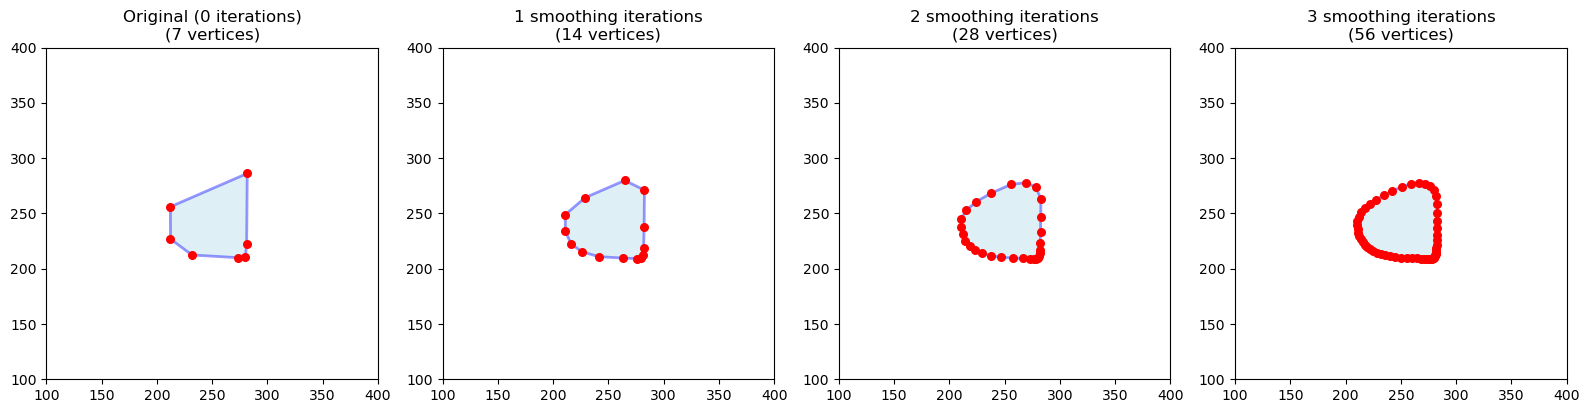

In [4]:
# Compare original vs smoothed polygons
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original polygon
elem = element.generate()
original_polygon = elem.polygon

smoothing_levels = [0, 1, 2, 3]
for ax, n_iter in zip(axes, smoothing_levels):
    if n_iter == 0:
        poly = original_polygon
        title = 'Original (0 iterations)'
    else:
        poly = smooth_polygon(original_polygon, iterations=n_iter, preserve_area=True)
        title = f'{n_iter} smoothing iterations'
    
    x, y = poly.exterior.xy
    ax.fill(x, y, alpha=0.4, fc='lightblue', ec='blue', linewidth=2)
    ax.scatter(x[:-1], y[:-1], c='red', s=30, zorder=5)  # Mark vertices
    ax.set_xlim(100, 400)
    ax.set_ylim(100, 400)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\n({len(x)-1} vertices)')

plt.tight_layout()
plt.show()

---
## 3. VacuolatedStructure: Structures with Central Holes

Many biological structures have **lumens** or **vacuoles** - hollow centers:
- Blood vessels
- Glands with secretory lumens
- Tubular structures

`VacuolatedStructure` creates ring-shaped elements with cells only in the annular region.

In [5]:
# Create a vacuolated structure (like a gland)
gland = VacuolatedStructure(
    frame_size=500,
    n_vertices=(10, 14),
    scale=120,
    fixed_center=np.array([[250, 250]]),
    tipical_cell_spacing=8,
    hole_scale_factor=0.6,  # Hole is 60% the size of outer polygon
    rules=RandomCellTypeRule(n_cell_types=n_cell_types)
)

gland_realized = gland.generate()

print(f"Generated gland with {len(gland_realized.cell_centroids)} cells")
print(f"Hole scale factor: {gland.hole_scale_factor}")

Generated gland with 69 cells
Hole scale factor: 0.6


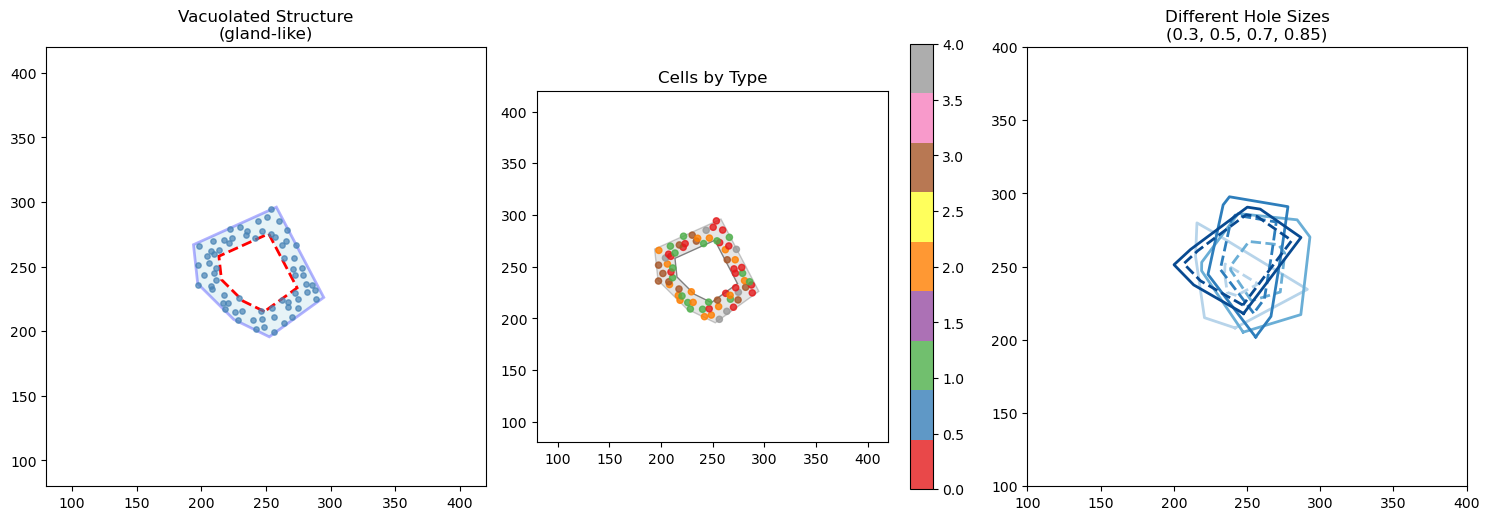

In [6]:
# Visualize the vacuolated structure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Structure with hole
ax = axes[0]
# Outer polygon
x, y = gland_realized.polygon.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2)
# Inner hole (fill with white)
x_hole, y_hole = gland_realized.hole.exterior.xy
ax.fill(x_hole, y_hole, fc='white', ec='red', linewidth=2, linestyle='--')
# Cells
ax.scatter(gland_realized.cell_centroids[:, 0], gland_realized.cell_centroids[:, 1],
           s=15, c='steelblue', alpha=0.7)
ax.set_xlim(80, 420)
ax.set_ylim(80, 420)
ax.set_aspect('equal')
ax.set_title('Vacuolated Structure\n(gland-like)')

# Plot 2: Cells colored by type
ax = axes[1]
x, y = gland_realized.polygon.exterior.xy
ax.fill(x, y, alpha=0.2, fc='gray', ec='black', linewidth=1)
x_hole, y_hole = gland_realized.hole.exterior.xy
ax.fill(x_hole, y_hole, fc='white', ec='gray', linewidth=1)
scatter = ax.scatter(gland_realized.cell_centroids[:, 0], gland_realized.cell_centroids[:, 1],
                     c=gland_realized.class_instance, cmap='Set1', s=20, alpha=0.8)
ax.set_xlim(80, 420)
ax.set_ylim(80, 420)
ax.set_aspect('equal')
ax.set_title('Cells by Type')
plt.colorbar(scatter, ax=ax)

# Plot 3: Different hole sizes
ax = axes[2]
hole_sizes = [0.3, 0.5, 0.7, 0.85]
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(hole_sizes)))
for hole_size, color in zip(hole_sizes, colors):
    g = VacuolatedStructure(
        frame_size=500, scale=100, 
        fixed_center=np.array([[250, 250]]),
        hole_scale_factor=hole_size,
        rules=RandomCellTypeRule(n_cell_types=5)
    ).generate()
    x, y = g.polygon.exterior.xy
    ax.plot(x, y, color=color, linewidth=2)
    x_h, y_h = g.hole.exterior.xy
    ax.plot(x_h, y_h, color=color, linewidth=2, linestyle='--')
ax.set_xlim(100, 400)
ax.set_ylim(100, 400)
ax.set_aspect('equal')
ax.set_title('Different Hole Sizes\n(0.3, 0.5, 0.7, 0.85)')

plt.tight_layout()
plt.show()

---
## 4. Cell Type Assignment Rules

Rules determine how cell type probabilities are assigned within elements. PointillSim provides several built-in rules, each modeling different biological patterns.

### 4.1 RandomCellTypeRule

Assigns random probabilities from a **Dirichlet distribution**. Each cell gets an independent draw.

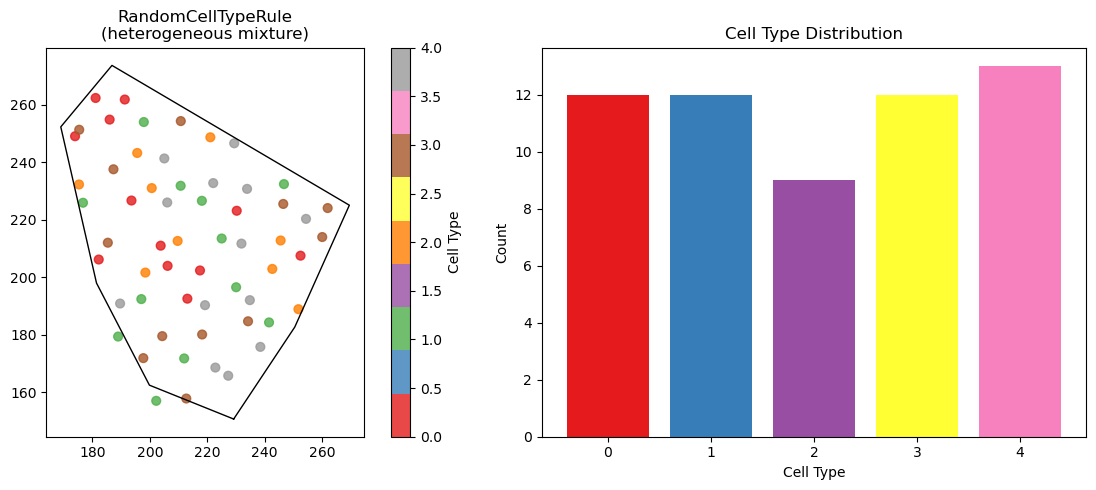

In [7]:
# RandomCellTypeRule creates heterogeneous mixtures
rule = RandomCellTypeRule(n_cell_types=5)

# Create element with this rule
elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=12, rules=rule
).generate()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Spatial distribution
ax = axes[0]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', s=40, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('RandomCellTypeRule\n(heterogeneous mixture)')
plt.colorbar(scatter, ax=ax, label='Cell Type')

# Cell type distribution
ax = axes[1]
types, counts = np.unique(elem.class_instance, return_counts=True)
ax.bar(types, counts, color=plt.cm.Set1(types / 5))
ax.set_xlabel('Cell Type')
ax.set_ylabel('Count')
ax.set_title('Cell Type Distribution')

plt.tight_layout()
plt.show()

### 4.2 SingleTypeRule

All cells in the element are assigned to a **single specific type** with probability 1.0.

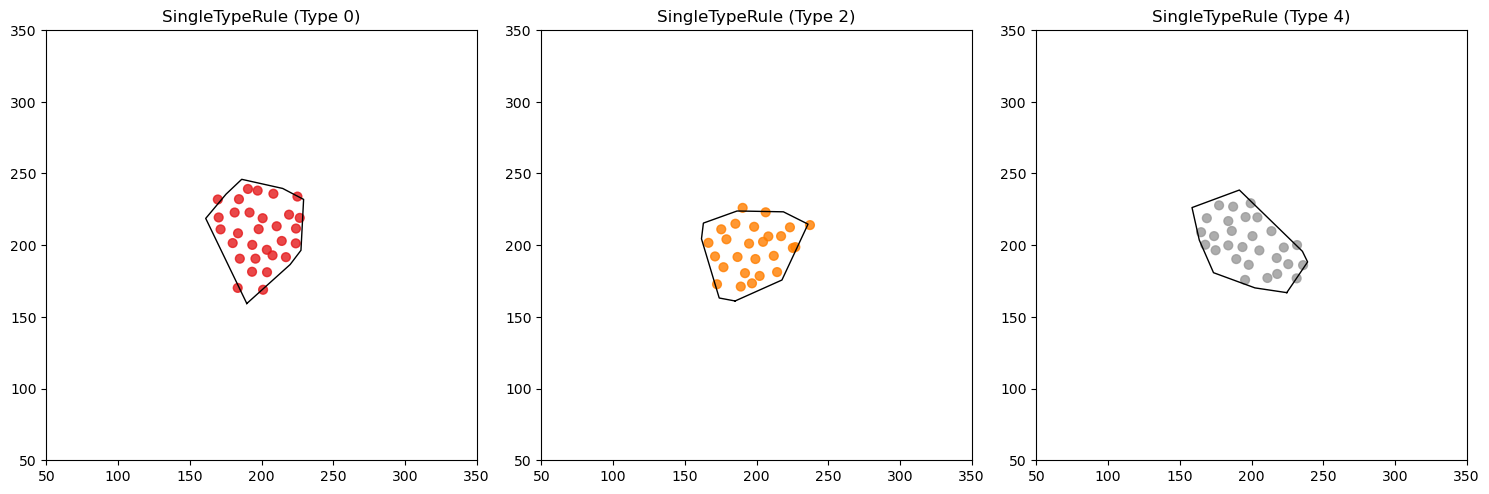

In [8]:
# SingleTypeRule - all cells same type
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cell_type in zip(axes, [0, 2, 4]):
    rule = SingleTypeRule(n_cell_types=5, cell_type_ix=cell_type)
    elem = HistologicalElement(
        frame_size=400, scale=100, fixed_center=np.array([[200, 200]]),
        tipical_cell_spacing=12, rules=rule
    ).generate()
    
    scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                         c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                         s=40, alpha=0.8)
    x, y = elem.polygon.exterior.xy
    ax.plot(x, y, 'k-', linewidth=1)
    ax.set_aspect('equal')
    ax.set_title(f'SingleTypeRule (Type {cell_type})')
    ax.set_xlim(50, 350)
    ax.set_ylim(50, 350)

plt.tight_layout()
plt.show()

### 4.3 MixOfNCellTypesRule

All cells receive the **same fixed mixture** of selected cell types. Useful for modeling regions with known composition.

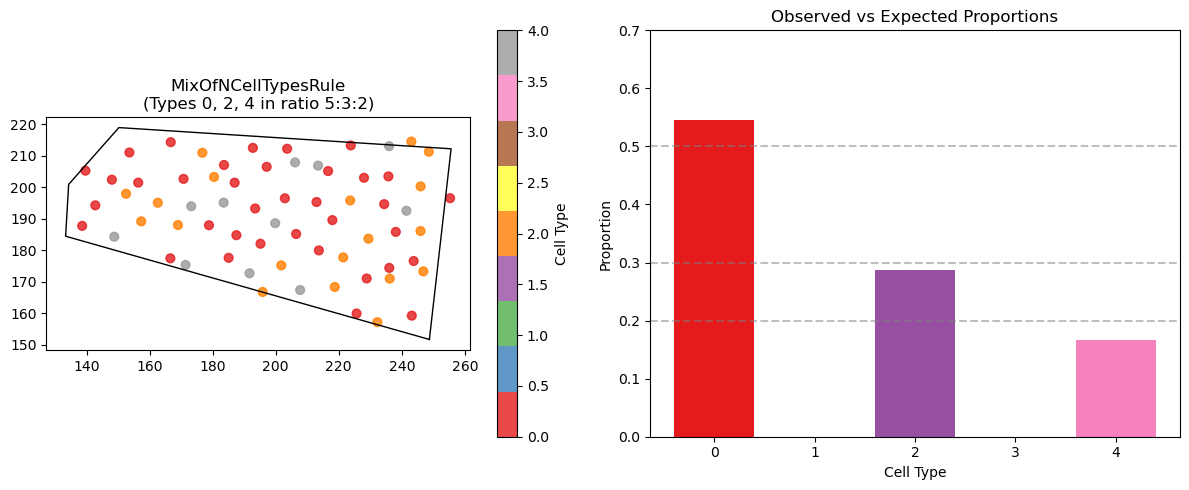

In [9]:
# MixOfNCellTypesRule - fixed proportions
rule = MixOfNCellTypesRule(
    n_cell_types=5,
    list_N=[0, 2, 4],           # Only these types present
    proportions=[0.5, 0.3, 0.2]  # In these proportions
)

elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=10, rules=rule
).generate()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                     s=40, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('MixOfNCellTypesRule\n(Types 0, 2, 4 in ratio 5:3:2)')
plt.colorbar(scatter, ax=ax, label='Cell Type')

ax = axes[1]
types, counts = np.unique(elem.class_instance, return_counts=True)
ax.bar(types, counts / counts.sum(), color=plt.cm.Set1(types / 5))
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Expected')
ax.axhline(0.3, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0.2, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Cell Type')
ax.set_ylabel('Proportion')
ax.set_title('Observed vs Expected Proportions')
ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()

### 4.4 DistanceBasedRule

Creates **radial patterns** by assigning cell types based on distance from the element center (or boundary). This models:
- Zonal organization in organs (liver lobules, adrenal zones)
- Peripheral vs central cell populations
- Gradient-like distributions

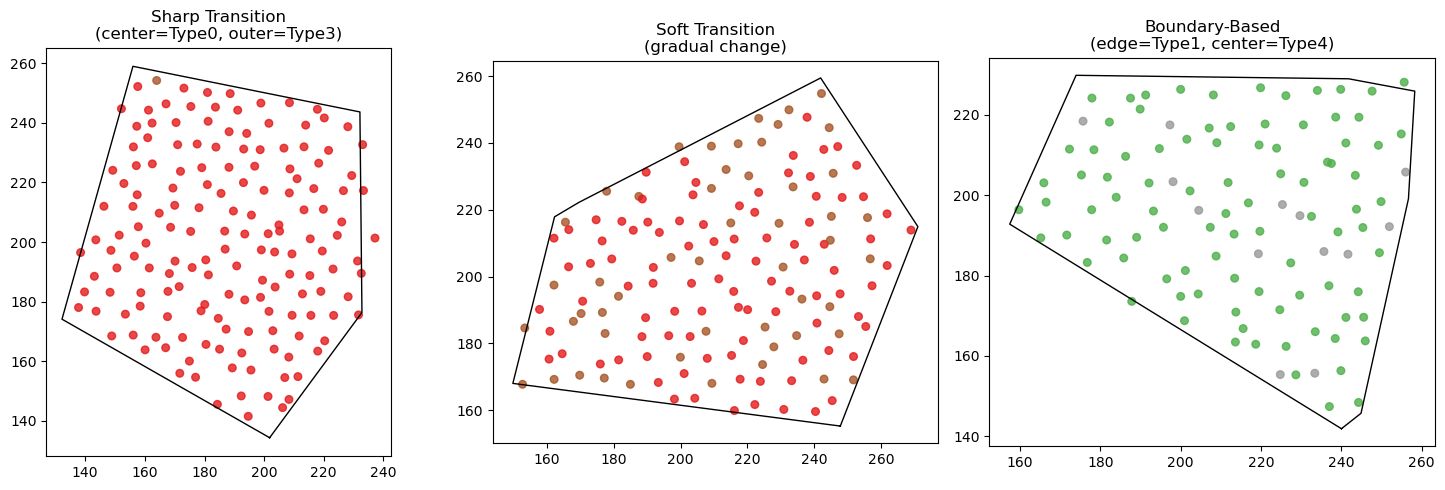

In [10]:
# DistanceBasedRule - radial patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sharp transition
rule = DistanceBasedRule(
    n_cell_types=5,
    reference='center',
    inner_type=0,
    outer_type=3,
    transition_width=10,
    sharpness=2.0
)
elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=8, rules=rule
).generate()

ax = axes[0]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                     s=30, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Sharp Transition\n(center=Type0, outer=Type3)')

# Soft transition
rule = DistanceBasedRule(
    n_cell_types=5,
    reference='center',
    inner_type=0,
    outer_type=3,
    transition_width=50,
    sharpness=0.5
)
elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=8, rules=rule
).generate()

ax = axes[1]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                     s=30, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Soft Transition\n(gradual change)')

# Boundary-based
rule = DistanceBasedRule(
    n_cell_types=5,
    reference='boundary',
    inner_type=1,  # Near boundary
    outer_type=4,  # Far from boundary (center)
    transition_width=30
)
elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=8, rules=rule
).generate()

ax = axes[2]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                     s=30, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Boundary-Based\n(edge=Type1, center=Type4)')

plt.tight_layout()
plt.show()

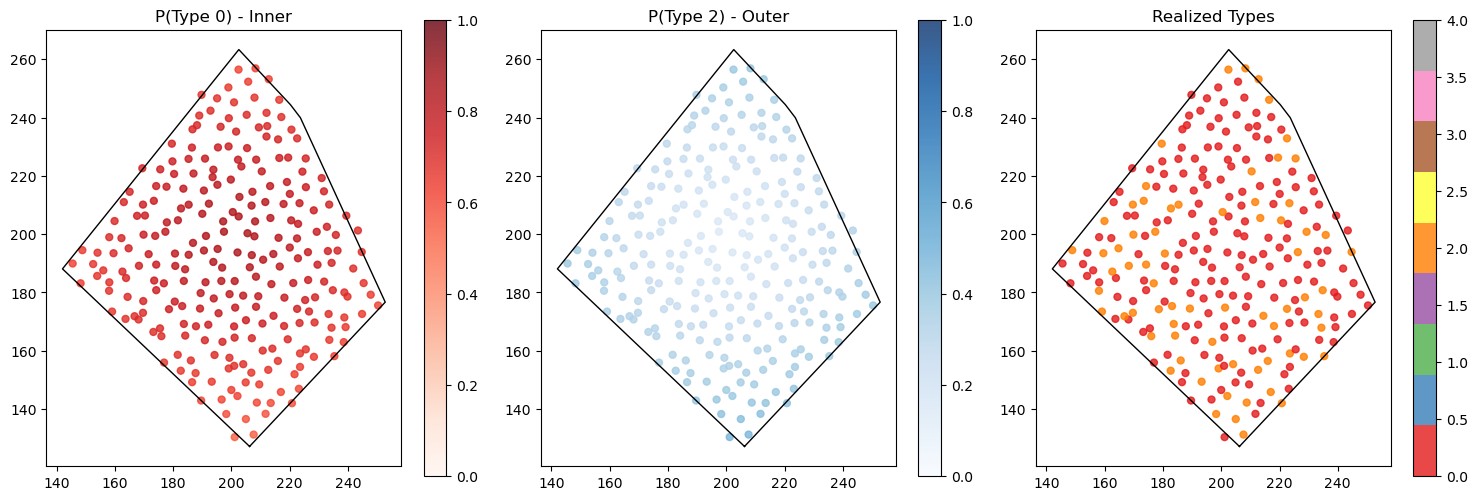

In [11]:
# Visualize the probability gradient (not just realized types)
rule = DistanceBasedRule(
    n_cell_types=5,
    reference='center',
    inner_type=0,
    outer_type=2,
    transition_width=40,
    sharpness=1.0
)
elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=6, rules=rule
).generate()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# P(Type 0) - inner type
ax = axes[0]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.cell_probabilities[:, 0], cmap='Reds',
                     vmin=0, vmax=1, s=25, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('P(Type 0) - Inner')
plt.colorbar(scatter, ax=ax)

# P(Type 2) - outer type
ax = axes[1]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.cell_probabilities[:, 2], cmap='Blues',
                     vmin=0, vmax=1, s=25, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('P(Type 2) - Outer')
plt.colorbar(scatter, ax=ax)

# Realized types
ax = axes[2]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                     s=25, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Realized Types')
plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

### 4.5 CompositeRule

Combines multiple rules with **configurable weights**. Use this to:
- Add noise to structured patterns
- Blend different assignment strategies
- Create complex spatial patterns

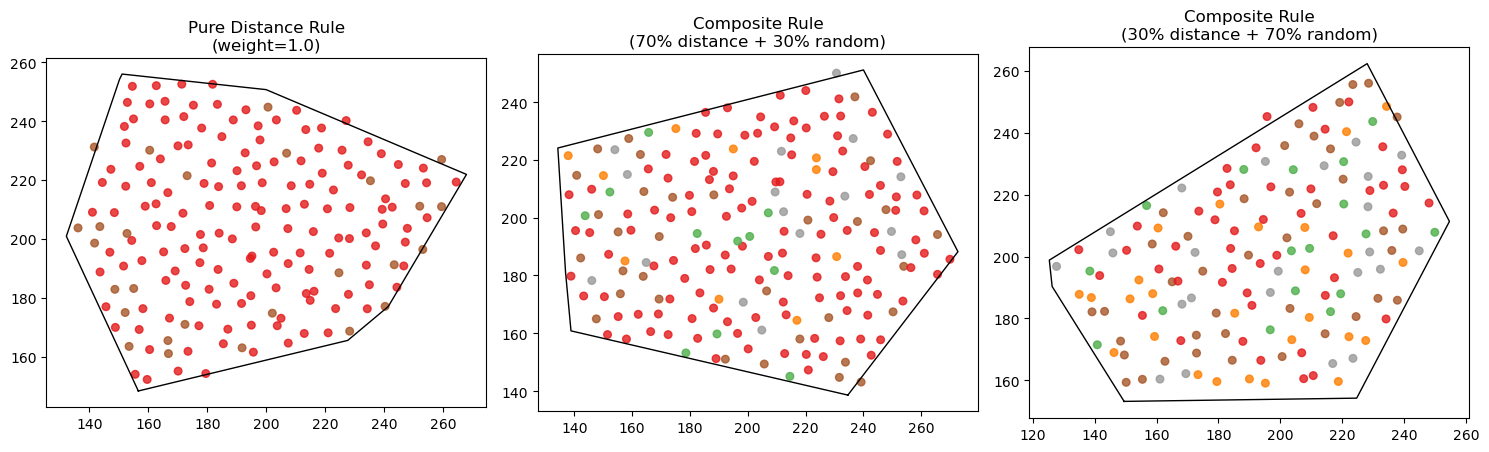

In [12]:
# CompositeRule - combine distance pattern with random noise
distance_rule = DistanceBasedRule(
    n_cell_types=5,
    reference='center',
    inner_type=0,
    outer_type=3
)
random_rule = RandomCellTypeRule(n_cell_types=5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pure distance-based
elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=8, rules=distance_rule
).generate()
ax = axes[0]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                     s=30, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Pure Distance Rule\n(weight=1.0)')

# 70% distance + 30% random
composite = CompositeRule(
    rules=[distance_rule, random_rule],
    weights=[0.7, 0.3],
    mode='average'
)
elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=8, rules=composite
).generate()
ax = axes[1]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                     s=30, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Composite Rule\n(70% distance + 30% random)')

# 30% distance + 70% random
composite2 = CompositeRule(
    rules=[distance_rule, random_rule],
    weights=[0.3, 0.7],
    mode='average'
)
elem = HistologicalElement(
    frame_size=400, scale=150, fixed_center=np.array([[200, 200]]),
    tipical_cell_spacing=8, rules=composite2
).generate()
ax = axes[2]
scatter = ax.scatter(elem.cell_centroids[:, 0], elem.cell_centroids[:, 1],
                     c=elem.class_instance, cmap='Set1', vmin=0, vmax=4,
                     s=30, alpha=0.8)
x, y = elem.polygon.exterior.xy
ax.plot(x, y, 'k-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Composite Rule\n(30% distance + 70% random)')

plt.tight_layout()
plt.show()

---
## 5. Combining Background and Foreground

Real tissue simulations combine:
1. **Background element**: Fills the FOV (e.g., stroma, parenchyma)
2. **Foreground elements**: Discrete structures placed on top

When elements overlap, **foreground "punches through" background** - background cells within foreground boundaries are removed.

In [13]:
# Create a FOV with background and one foreground structure
n_cell_types = 5
frame_size = 500

# Background: random mixture (stromal tissue)
background = lambda: FrameWideElement(
    frame_size=frame_size,
    tipical_cell_spacing=12,
    rules=RandomCellTypeRule(n_cell_types=n_cell_types)
)

# Foreground: distance-based structure (e.g., tumor nodule)
foreground = lambda: HistologicalElement(
    frame_size=frame_size,
    scale=100,
    tipical_cell_spacing=10,
    rules=DistanceBasedRule(
        n_cell_types=n_cell_types,
        inner_type=1,
        outer_type=4,
        transition_width=30
    )
)

fov_dist = FOVDistribution(
    frame_size=frame_size,
    background_element=background,
    other_elements=[foreground],
    elements_frequency=[1.0],  # Always include the foreground
)

fov = fov_dist.generate_fov()

print(f"Generated FOV with {fov.n_cells} cells")

Generated FOV with 2005 cells


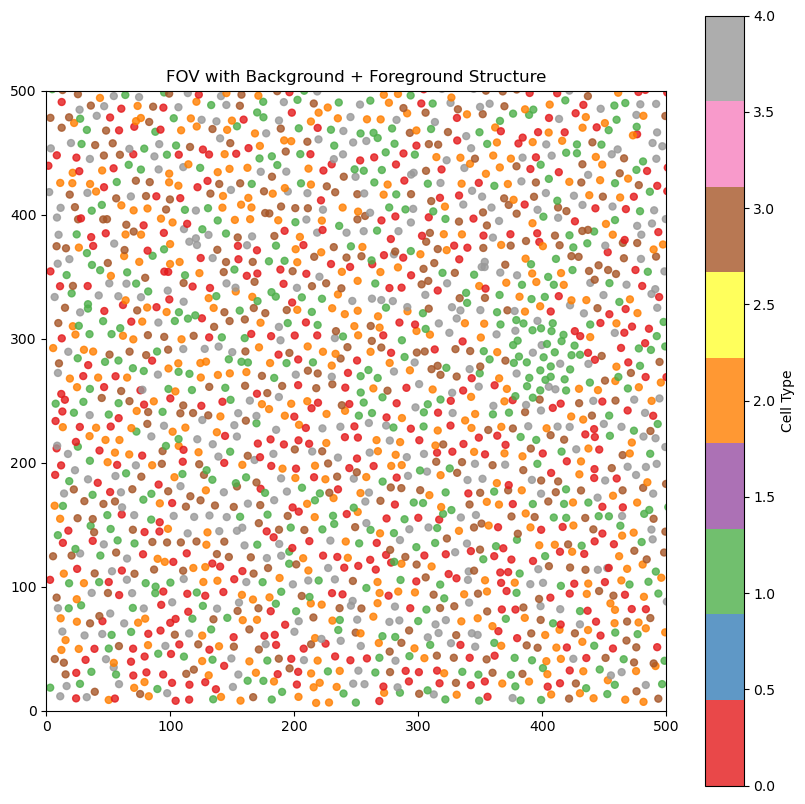

In [14]:
# Visualize the combined FOV
fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    fov.cell_centroids[:, 0],
    fov.cell_centroids[:, 1],
    c=fov.class_instance,
    cmap='Set1',
    s=25, alpha=0.8
)

ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title('FOV with Background + Foreground Structure')
plt.colorbar(scatter, ax=ax, label='Cell Type')

plt.show()

### Multiple Foreground Structures

You can add multiple structures with different probabilities.

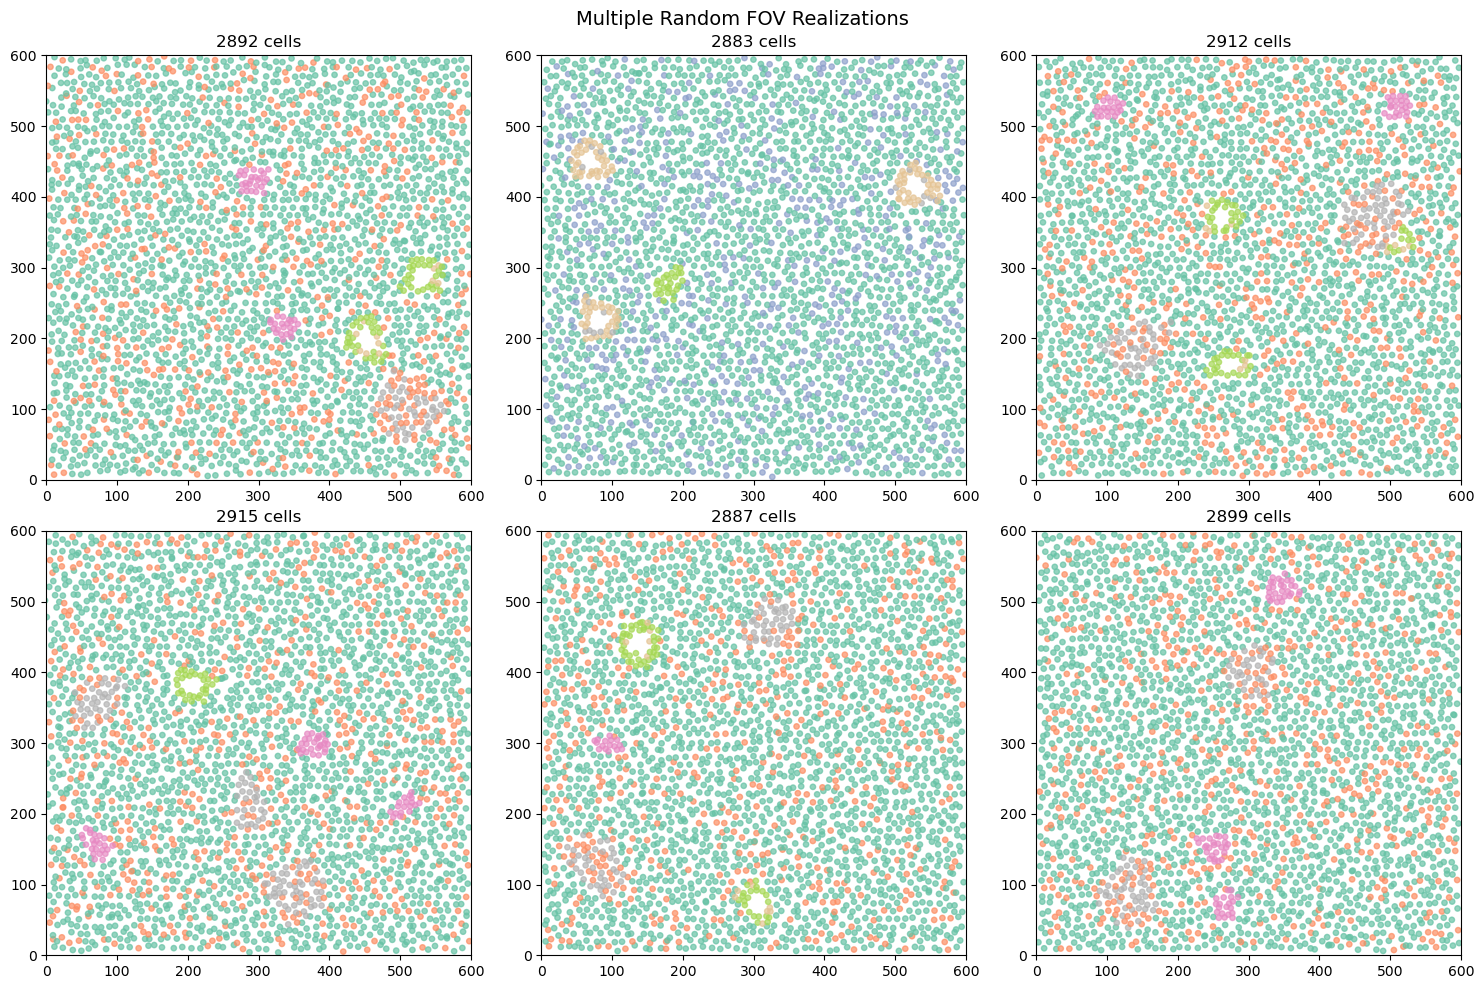

In [15]:
# Multiple structure types
n_cell_types = 6
frame_size = 600

# Background: Type 0 dominant
background = lambda: FrameWideElement(
    frame_size=frame_size,
    tipical_cell_spacing=12,
    rules=MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[0, 1], proportions=[0.8, 0.2])
)

# Structure type 1: Small nodule (Type 2 core)
nodule = lambda: HistologicalElement(
    frame_size=frame_size,
    scale=60,
    tipical_cell_spacing=8,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=2)
)

# Structure type 2: Gland with lumen
gland = lambda: VacuolatedStructure(
    frame_size=frame_size,
    scale=80,
    hole_scale_factor=0.5,
    tipical_cell_spacing=8,
    rules=DistanceBasedRule(
        n_cell_types=n_cell_types,
        reference='boundary',  # Near lumen = inner
        inner_type=3,  # Luminal cells
        outer_type=4,  # Basal cells
        transition_width=15
    )
)

# Structure type 3: Large region with gradient
large_region = lambda: HistologicalElement(
    frame_size=frame_size,
    scale=120,
    tipical_cell_spacing=10,
    rules=DistanceBasedRule(
        n_cell_types=n_cell_types,
        inner_type=5,
        outer_type=1,
        transition_width=40
    )
)

fov_dist = FOVDistribution(
    frame_size=frame_size,
    background_element=background,
    other_elements=[nodule, gland, large_region],
    elements_frequency=[0.7, 0.6, 0.4],  # Probability of including each
    attempts_at_elements=3,  # Try to place each up to 3 times
)

# Generate multiple FOVs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax in axes.flat:
    fov = fov_dist.generate_fov()
    scatter = ax.scatter(
        fov.cell_centroids[:, 0],
        fov.cell_centroids[:, 1],
        c=fov.class_instance,
        cmap='Set2',
        s=15, alpha=0.7
    )
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'{fov.n_cells} cells')

plt.suptitle('Multiple Random FOV Realizations', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Complex Simulation Examples

Let's create a complete simulation with realistic tissue architecture.

In [16]:
# Define a tissue with specific cell types
cell_type_names = [
    "Stromal",       # 0
    "Epithelial",    # 1
    "Luminal",       # 2
    "Basal",         # 3
    "Immune",        # 4
]
n_cell_types = len(cell_type_names)

# Create tissue expression profiles
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=30,
    n_cell_types=n_cell_types,
    expected_level=10,
    concentration=0.85
)

# Cell morphology (different sizes per type)
cell_props = CellTypesProperties(
    n_cell_types=n_cell_types,
    sizes=[15, 12, 10, 14, 8],           # Stromal large, immune small
    anisotropy=[0.8, 0.9, 0.95, 0.85, 0.95],  # Stromal elongated
    relative_rna_concentration=[0.8, 1.2, 1.0, 1.1, 0.6],
)

In [17]:
# Build the FOV distribution
frame_size = 800

# Background: Stromal tissue with some immune cells
background = lambda: FrameWideElement(
    frame_size=frame_size,
    tipical_cell_spacing=18,
    rules=MixOfNCellTypesRule(
        n_cell_types=n_cell_types,
        list_N=[0, 4],  # Stromal and Immune
        proportions=[0.85, 0.15]
    )
)

# Glandular structure
gland = lambda: VacuolatedStructure(
    frame_size=frame_size,
    scale=80,
    hole_scale_factor=0.55,
    tipical_cell_spacing=10,
    rules=DistanceBasedRule(
        n_cell_types=n_cell_types,
        reference='boundary',
        inner_type=2,  # Luminal
        outer_type=3,  # Basal
        transition_width=12
    )
)

# Epithelial cluster
epithelial_cluster = lambda: HistologicalElement(
    frame_size=frame_size,
    scale=100,
    tipical_cell_spacing=12,
    rules=CompositeRule(
        rules=[
            SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=1),
            RandomCellTypeRule(n_cell_types=n_cell_types)
        ],
        weights=[0.85, 0.15]  # Mostly epithelial with some noise
    )
)

# Immune infiltrate
immune_focus = lambda: HistologicalElement(
    frame_size=frame_size,
    scale=50,
    tipical_cell_spacing=8,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=4)
)

fov_dist = FOVDistribution(
    frame_size=frame_size,
    background_element=background,
    other_elements=[gland, epithelial_cluster, immune_focus],
    elements_frequency=[0.5, 0.4, 0.3],
    attempts_at_elements=[2, 2, 3],
)

In [18]:
# Generate a complete FOV with all steps
fov = fov_dist.generate_fov()
cell_props.apply(fov)

hybiss = HybISS_Setup(
    tissue=tissue,
    genes_sensitivities=1.0,
    genes_sensitivities_variation=0.2
)
hybiss.observe_dots(fov)

dots_df = hybiss.make_pandas_df()
cells_df = fov.make_pandas_df()

print(f"Generated tissue with:")
print(f"  {fov.n_cells} cells")
print(f"  {len(dots_df)} transcript dots")
print(f"\nCell type distribution:")
for i, name in enumerate(cell_type_names):
    count = np.sum(fov.class_instance == i)
    print(f"  {name}: {count} ({100*count/fov.n_cells:.1f}%)")

Generated tissue with:
  2251 cells
  16440 transcript dots

Cell type distribution:
  Stromal: 1910 (84.9%)
  Epithelial: 0 (0.0%)
  Luminal: 13 (0.6%)
  Basal: 1 (0.0%)
  Immune: 327 (14.5%)


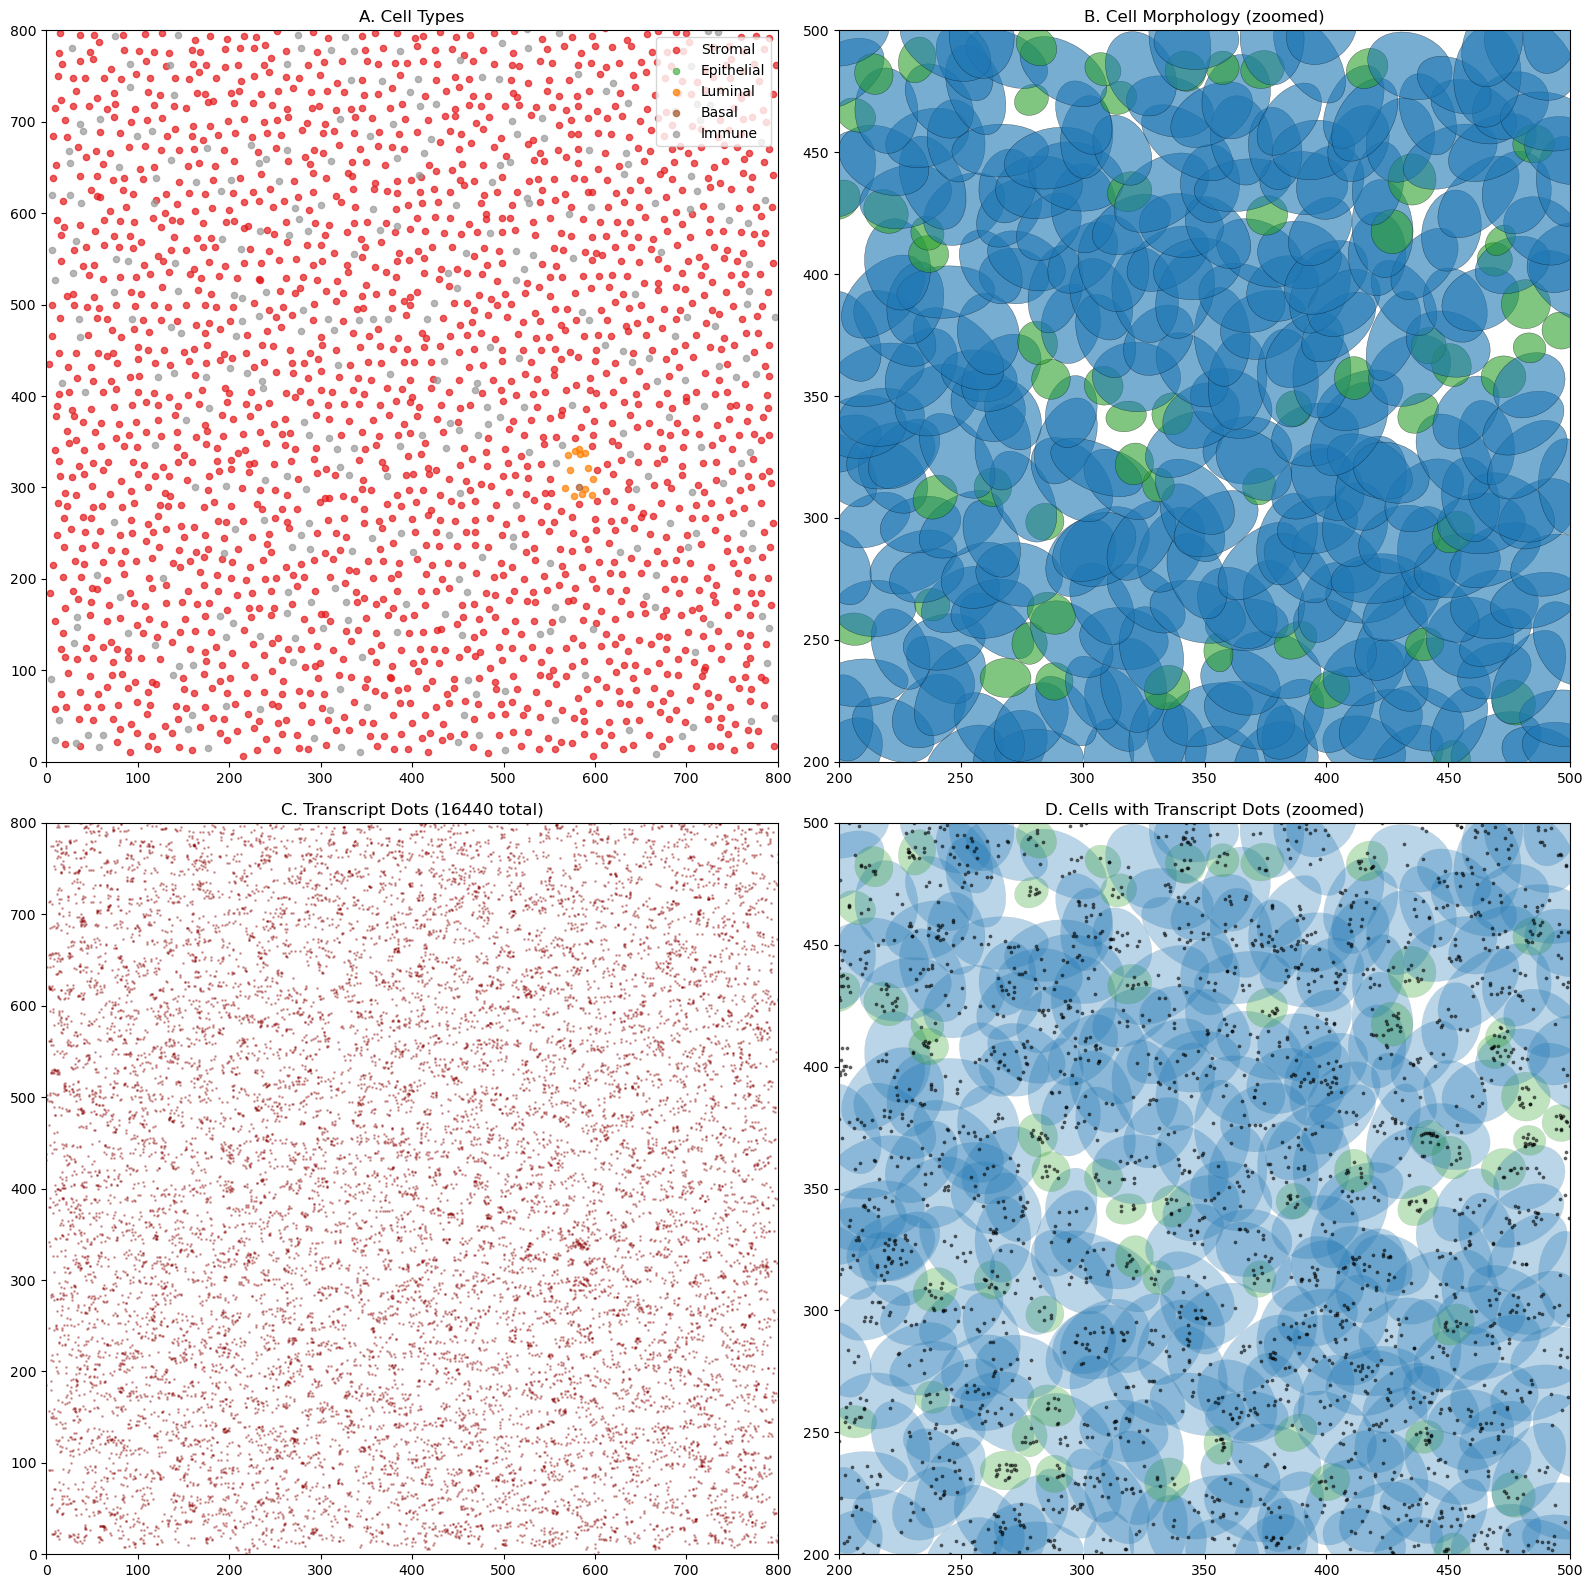

In [19]:
# Final comprehensive visualization
from matplotlib.patches import Ellipse, Patch
from matplotlib.collections import PatchCollection

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# A: Cell types by color
ax = axes[0, 0]
colors = plt.cm.Set1(np.linspace(0, 1, n_cell_types))
for i, (name, color) in enumerate(zip(cell_type_names, colors)):
    mask = fov.class_instance == i
    ax.scatter(
        fov.cell_centroids[mask, 0],
        fov.cell_centroids[mask, 1],
        c=[color], s=20, alpha=0.7, label=name
    )
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title('A. Cell Types')
ax.legend(loc='upper right')

# B: Cell morphology (zoomed)
ax = axes[0, 1]
x_min, x_max = 200, 500
y_min, y_max = 200, 500
mask = (
    (fov.cell_centroids[:, 0] >= x_min) & (fov.cell_centroids[:, 0] <= x_max) &
    (fov.cell_centroids[:, 1] >= y_min) & (fov.cell_centroids[:, 1] <= y_max)
)
ellipses = []
cell_colors = []
for i in np.where(mask)[0]:
    ellipse = Ellipse(
        xy=(fov.cell_centroids[i, 0], fov.cell_centroids[i, 1]),
        width=2 * fov.cell_major_axis[i],
        height=2 * fov.cell_minor_axis[i],
        angle=np.degrees(fov.cell_rotation[i]),
    )
    ellipses.append(ellipse)
    cell_colors.append(fov.cell_colors[i])
collection = PatchCollection(ellipses, alpha=0.6)
collection.set_facecolors(cell_colors)
collection.set_edgecolors('black')
collection.set_linewidths(0.3)
ax.add_collection(collection)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_aspect('equal')
ax.set_title('B. Cell Morphology (zoomed)')

# C: Transcript dots (full FOV)
ax = axes[1, 0]
ax.scatter(
    dots_df['x'], dots_df['y'],
    c='darkred', s=1, alpha=0.3
)
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title(f'C. Transcript Dots ({len(dots_df)} total)')

# D: Cells with dots (zoomed)
ax = axes[1, 1]
collection2 = PatchCollection([e for e in ellipses], alpha=0.3)
collection2.set_facecolors(cell_colors)
collection2.set_edgecolors('gray')
collection2.set_linewidths(0.2)
ax.add_collection(collection2)
mask_dots = (
    (dots_df['x'] >= x_min) & (dots_df['x'] <= x_max) &
    (dots_df['y'] >= y_min) & (dots_df['y'] <= y_max)
)
ax.scatter(
    dots_df.loc[mask_dots, 'x'],
    dots_df.loc[mask_dots, 'y'],
    c='black', s=3, alpha=0.5
)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_aspect('equal')
ax.set_title('D. Cells with Transcript Dots (zoomed)')

plt.tight_layout()
plt.show()

---
## Summary

This notebook covered:

### Histological Elements
| Element | Description |
|---------|-------------|
| `FrameWideElement` | Background tissue filling entire FOV |
| `HistologicalElement` | Bounded convex regions |
| `VacuolatedStructure` | Ring-shaped structures with holes |

### Cell Type Rules
| Rule | Pattern Created |
|------|----------------|
| `RandomCellTypeRule` | Heterogeneous random mixture |
| `SingleTypeRule` | All cells same type |
| `MixOfNCellTypesRule` | Fixed proportions of selected types |
| `DistanceBasedRule` | Radial gradients from center/boundary |
| `CompositeRule` | Weighted combination of rules |

### Key Concepts
1. **Elements define structure**: Shape and cell placement
2. **Rules define composition**: Cell type assignment
3. **FOVDistribution composes**: Background + foreground
4. **Foreground punches through**: No overlap ambiguity

### Next Steps

- Notebook 03: Batch generation of datasets
- Notebook 04: Loading real expression data